<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/Task07_Regression_Models_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# Load dataset
california = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target  # Target variable (in $100,000s)

print("="*60)
print("CALIFORNIA HOUSING DATASET")
print("="*60)
print(f"Dataset Shape: {df.shape}")
print(f"Features: {df.shape[1]-1}")
print(f"Samples: {df.shape[0]}")
print("\nFeature Names:")
print(california.feature_names)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Statistics:")
print(df.describe())

print("\nTarget Variable (MedHouseVal):")
print(f"Mean: ${df['MedHouseVal'].mean()*100000:,.2f}")
print(f"Min: ${df['MedHouseVal'].min()*100000:,.2f}")
print(f"Max: ${df['MedHouseVal'].max()*100000:,.2f}")
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

CALIFORNIA HOUSING DATASET
Dataset Shape: (20640, 9)
Features: 8
Samples: 20640

Feature Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20


FEATURE DESCRIPTIONS
MedInc: Median income in block group
HouseAge: Median house age in block group
AveRooms: Average number of rooms per household
AveBedrms: Average number of bedrooms per household
Population: Block group population
AveOccup: Average household size
Latitude: Block group latitude
Longitude: Block group longitude


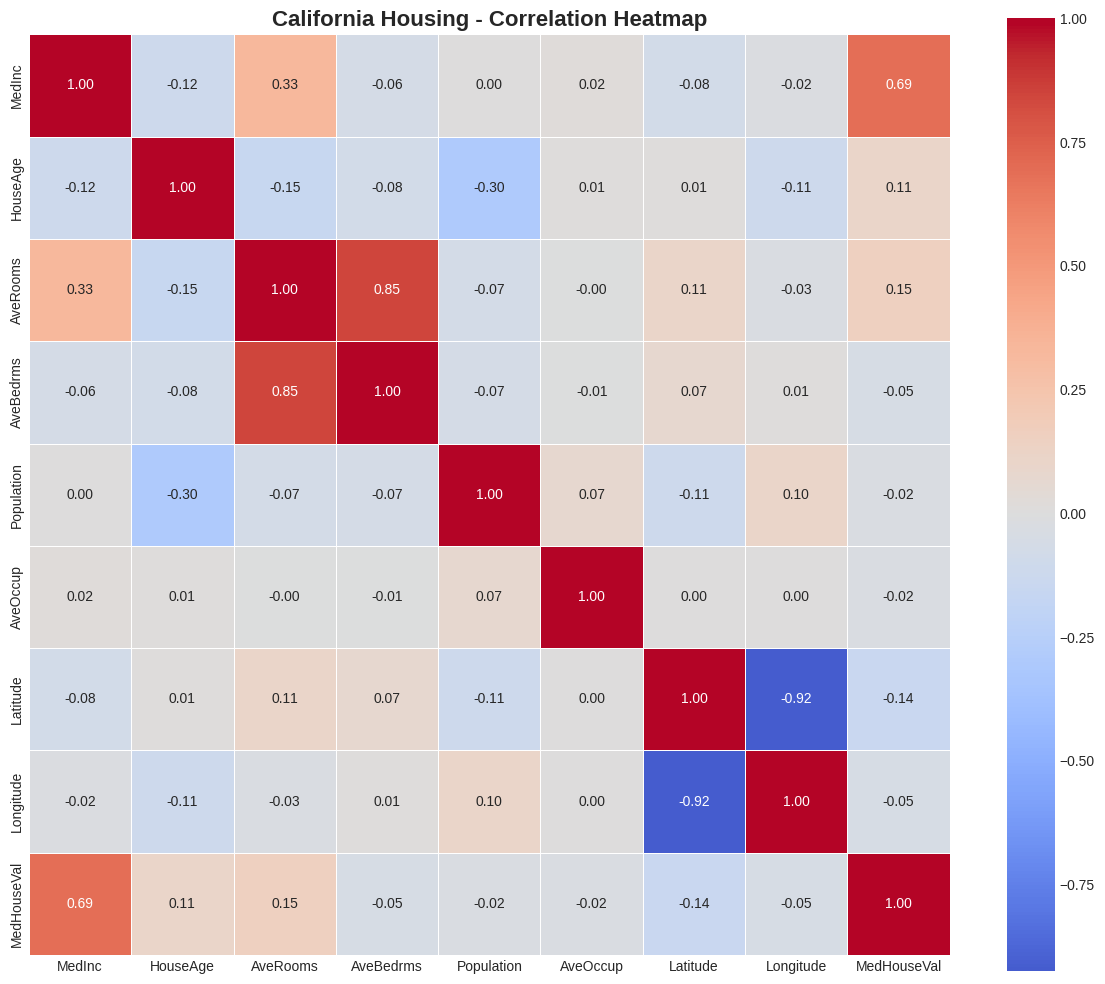

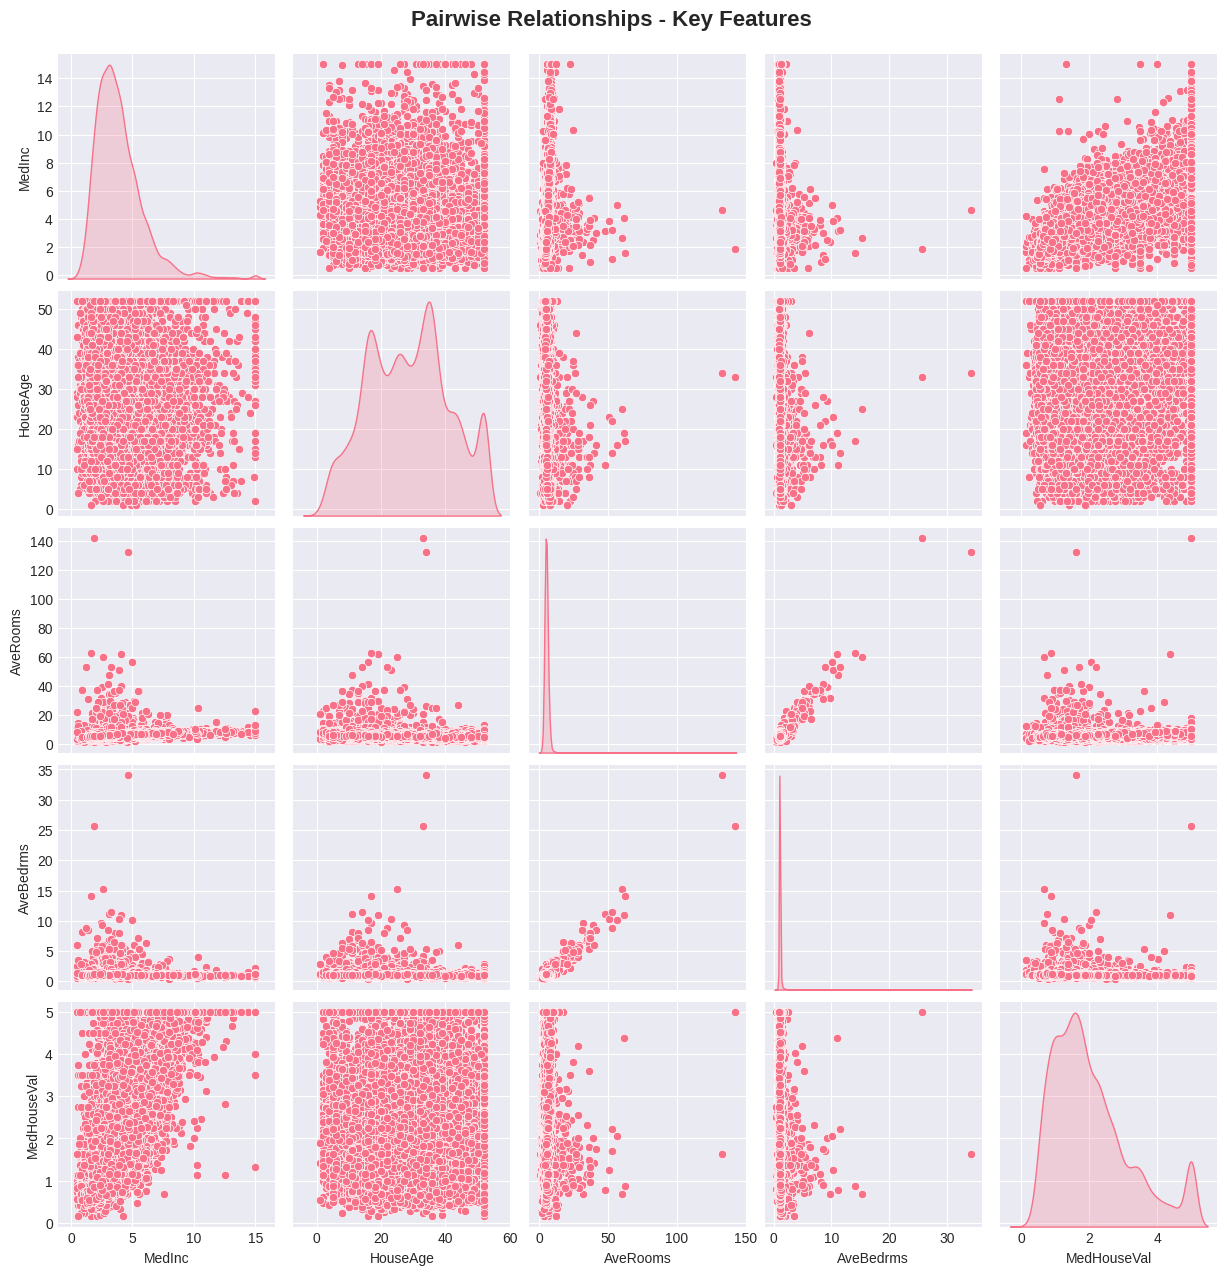

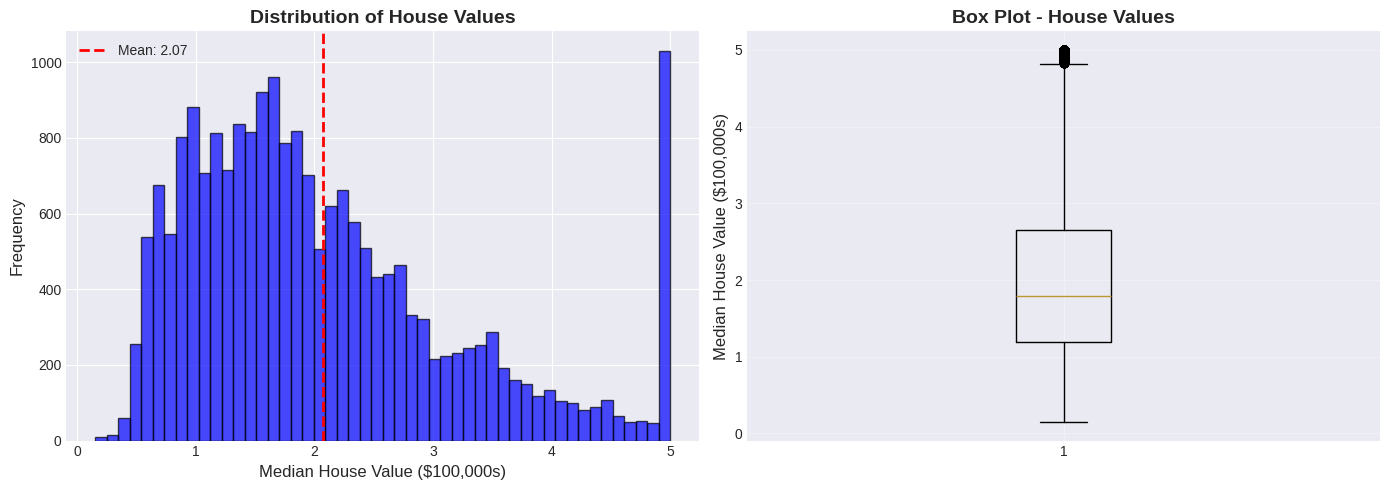

In [ ]:

feature_descriptions = {
    'MedInc': 'Median income in block group',
    'HouseAge': 'Median house age in block group',
    'AveRooms': 'Average number of rooms per household',
    'AveBedrms': 'Average number of bedrooms per household',
    'Population': 'Block group population',
    'AveOccup': 'Average household size',
    'Latitude': 'Block group latitude',
    'Longitude': 'Block group longitude'
}

print("\n" + "="*60)
print("FEATURE DESCRIPTIONS")
print("="*60)
for feature, desc in feature_descriptions.items():
    print(f"{feature}: {desc}")

# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('California Housing - Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Pairplot (selecting key features)
selected_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'MedHouseVal']
sns.pairplot(df[selected_features], diag_kind='kde', height=2.5)
plt.suptitle('Pairwise Relationships - Key Features', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_xlabel('Median House Value ($100,000s)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of House Values', fontsize=14, fontweight='bold')
axes[0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["MedHouseVal"].mean():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['MedHouseVal'])
axes[1].set_ylabel('Median House Value ($100,000s)', fontsize=12)
axes[1].set_title('Box Plot - House Values', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
print(df.isnull().sum())

# Split features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Feature scaling (important for interpretation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better visualization
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nFeature scaling complete!")
print("Before scaling:")
print(f"MedInc mean: {X_train['MedInc'].mean():.4f}, std: {X_train['MedInc'].std():.4f}")
print("After scaling:")
print(f"MedInc mean: {X_train_scaled_df['MedInc'].mean():.4f}, std: {X_train_scaled_df['MedInc'].std():.4f}")


MISSING VALUES CHECK
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Training set size: 16512
Test set size: 4128

Feature scaling complete!
Before scaling:
MedInc mean: 3.8808, std: 1.9043
After scaling:
MedInc mean: -0.0000, std: 1.0000



SIMPLE LINEAR REGRESSION (MedInc → House Value)
Equation: House Value = 0.4193 × MedInc + 0.4446
Slope: 0.4193 (for each $1 increase in income, value increases by $41,933.85)
Intercept: 0.4446

Model Performance:
MSE: 0.7091
RMSE: $84,209.01
MAE: $62,990.87
R² Score: 0.4589


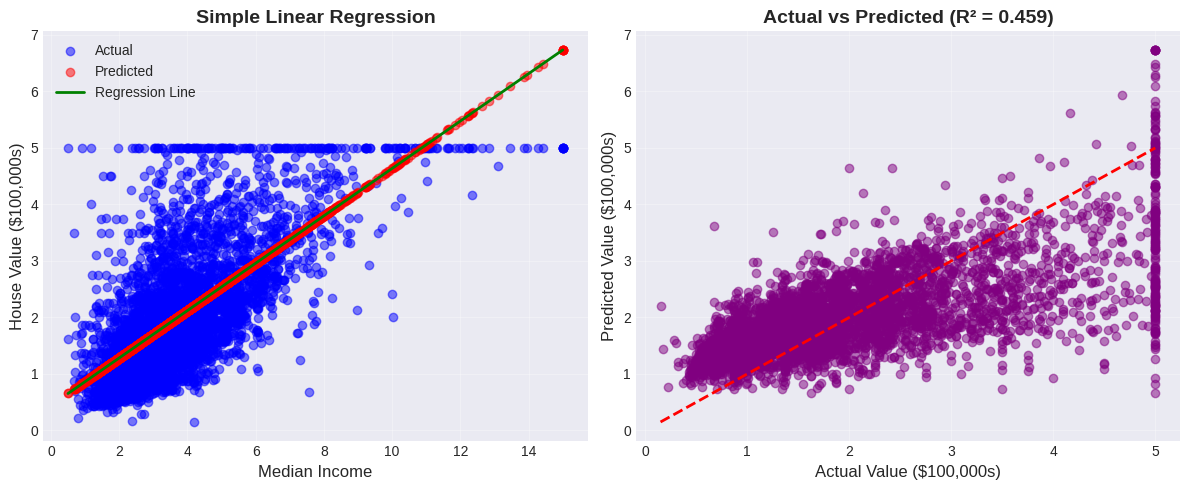

In [ ]:

X_simple = X_train[['MedInc']]
X_test_simple = X_test[['MedInc']]

# Create and train model
simple_model = LinearRegression()
simple_model.fit(X_simple, y_train)

# Predictions
y_pred_simple_train = simple_model.predict(X_simple)
y_pred_simple_test = simple_model.predict(X_test_simple)

# Results
print("\n" + "="*60)
print("SIMPLE LINEAR REGRESSION (MedInc → House Value)")
print("="*60)
print(f"Equation: House Value = {simple_model.coef_[0]:.4f} × MedInc + {simple_model.intercept_:.4f}")
print(f"Slope: {simple_model.coef_[0]:.4f} (for each $1 increase in income, value increases by ${simple_model.coef_[0]*100000:,.2f})")
print(f"Intercept: {simple_model.intercept_:.4f}")

# Evaluation
simple_mse = mean_squared_error(y_test, y_pred_simple_test)
simple_rmse = np.sqrt(simple_mse)
simple_r2 = r2_score(y_test, y_pred_simple_test)
simple_mae = mean_absolute_error(y_test, y_pred_simple_test)

print(f"\nModel Performance:")
print(f"MSE: {simple_mse:.4f}")
print(f"RMSE: ${simple_rmse*100000:,.2f}")
print(f"MAE: ${simple_mae*100000:,.2f}")
print(f"R² Score: {simple_r2:.4f}")

# Visualization
plt.figure(figsize=(12, 5))

# Scatter plot with regression line
plt.subplot(1, 2, 1)
plt.scatter(X_test_simple, y_test, alpha=0.5, color='blue', label='Actual')
plt.scatter(X_test_simple, y_pred_simple_test, alpha=0.5, color='red', label='Predicted')
x_range = np.linspace(X_simple.min(), X_simple.max(), 100)
y_range = simple_model.predict(x_range.reshape(-1, 1))
plt.plot(x_range, y_range, 'green', linewidth=2, label='Regression Line')
plt.xlabel('Median Income', fontsize=12)
plt.ylabel('House Value ($100,000s)', fontsize=12)
plt.title('Simple Linear Regression', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Actual vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_simple_test, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'red', linestyle='--', linewidth=2)
plt.xlabel('Actual Value ($100,000s)', fontsize=12)
plt.ylabel('Predicted Value ($100,000s)', fontsize=12)
plt.title(f'Actual vs Predicted (R² = {simple_r2:.3f})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


MULTIPLE LINEAR REGRESSION (All Features)

Model Coefficients (scaled features):
   Feature  Coefficient  Coefficient ($)
    MedInc     0.854383     85438.303093
 AveBedrms     0.339259     33925.949059
  HouseAge     0.122546     12254.623808
Population    -0.002308      -230.772315
  AveOccup    -0.040829     -4082.910309
  AveRooms    -0.294410    -29441.013447
 Longitude    -0.869842    -86984.177524
  Latitude    -0.896929    -89692.887664

Intercept: 2.0719

Model Performance:
MSE: 0.5559
RMSE: $74,558.14
MAE: $53,320.01
R² Score: 0.5758


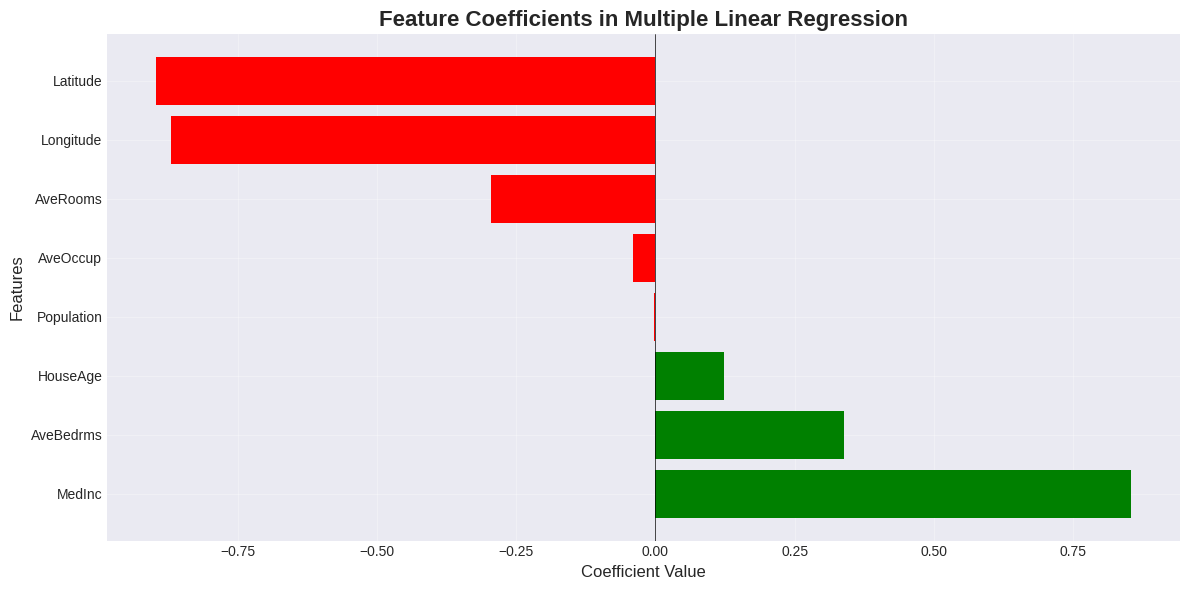

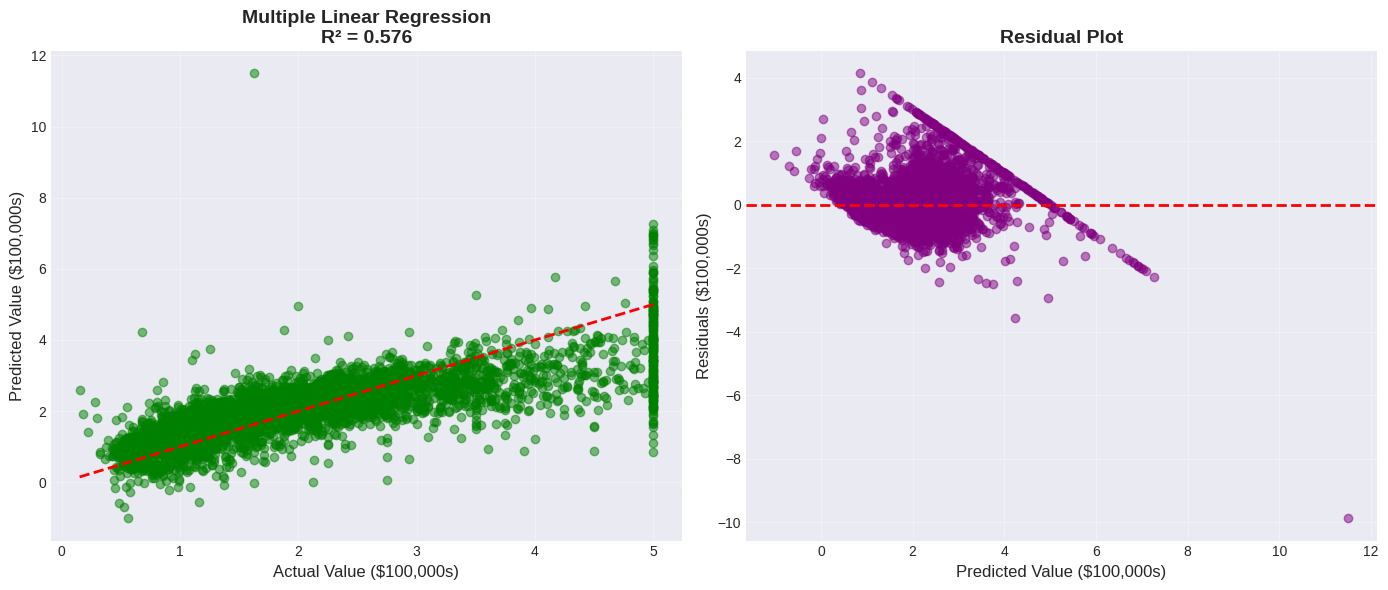

In [ ]:

multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_multi_train = multi_model.predict(X_train_scaled)
y_pred_multi_test = multi_model.predict(X_test_scaled)

# Results
print("\n" + "="*60)
print("MULTIPLE LINEAR REGRESSION (All Features)")
print("="*60)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multi_model.coef_,
    'Coefficient ($)': multi_model.coef_ * 100000
}).sort_values('Coefficient', ascending=False)

print("\nModel Coefficients (scaled features):")
print(coef_df.to_string(index=False))

print(f"\nIntercept: {multi_model.intercept_:.4f}")

# Evaluation
multi_mse = mean_squared_error(y_test, y_pred_multi_test)
multi_rmse = np.sqrt(multi_mse)
multi_r2 = r2_score(y_test, y_pred_multi_test)
multi_mae = mean_absolute_error(y_test, y_pred_multi_test)

print(f"\nModel Performance:")
print(f"MSE: {multi_mse:.4f}")
print(f"RMSE: ${multi_rmse*100000:,.2f}")
print(f"MAE: ${multi_mae*100000:,.2f}")
print(f"R² Score: {multi_r2:.4f}")

# Visualize coefficients
plt.figure(figsize=(12, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Coefficients in Multiple Linear Regression', fontsize=16, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_multi_test, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'red', linestyle='--', linewidth=2)
plt.xlabel('Actual Value ($100,000s)', fontsize=12)
plt.ylabel('Predicted Value ($100,000s)', fontsize=12)
plt.title(f'Multiple Linear Regression\nR² = {multi_r2:.3f}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred_multi_test
plt.subplot(1, 2, 2)
plt.scatter(y_pred_multi_test, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Value ($100,000s)', fontsize=12)
plt.ylabel('Residuals ($100,000s)', fontsize=12)
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


POLYNOMIAL REGRESSION


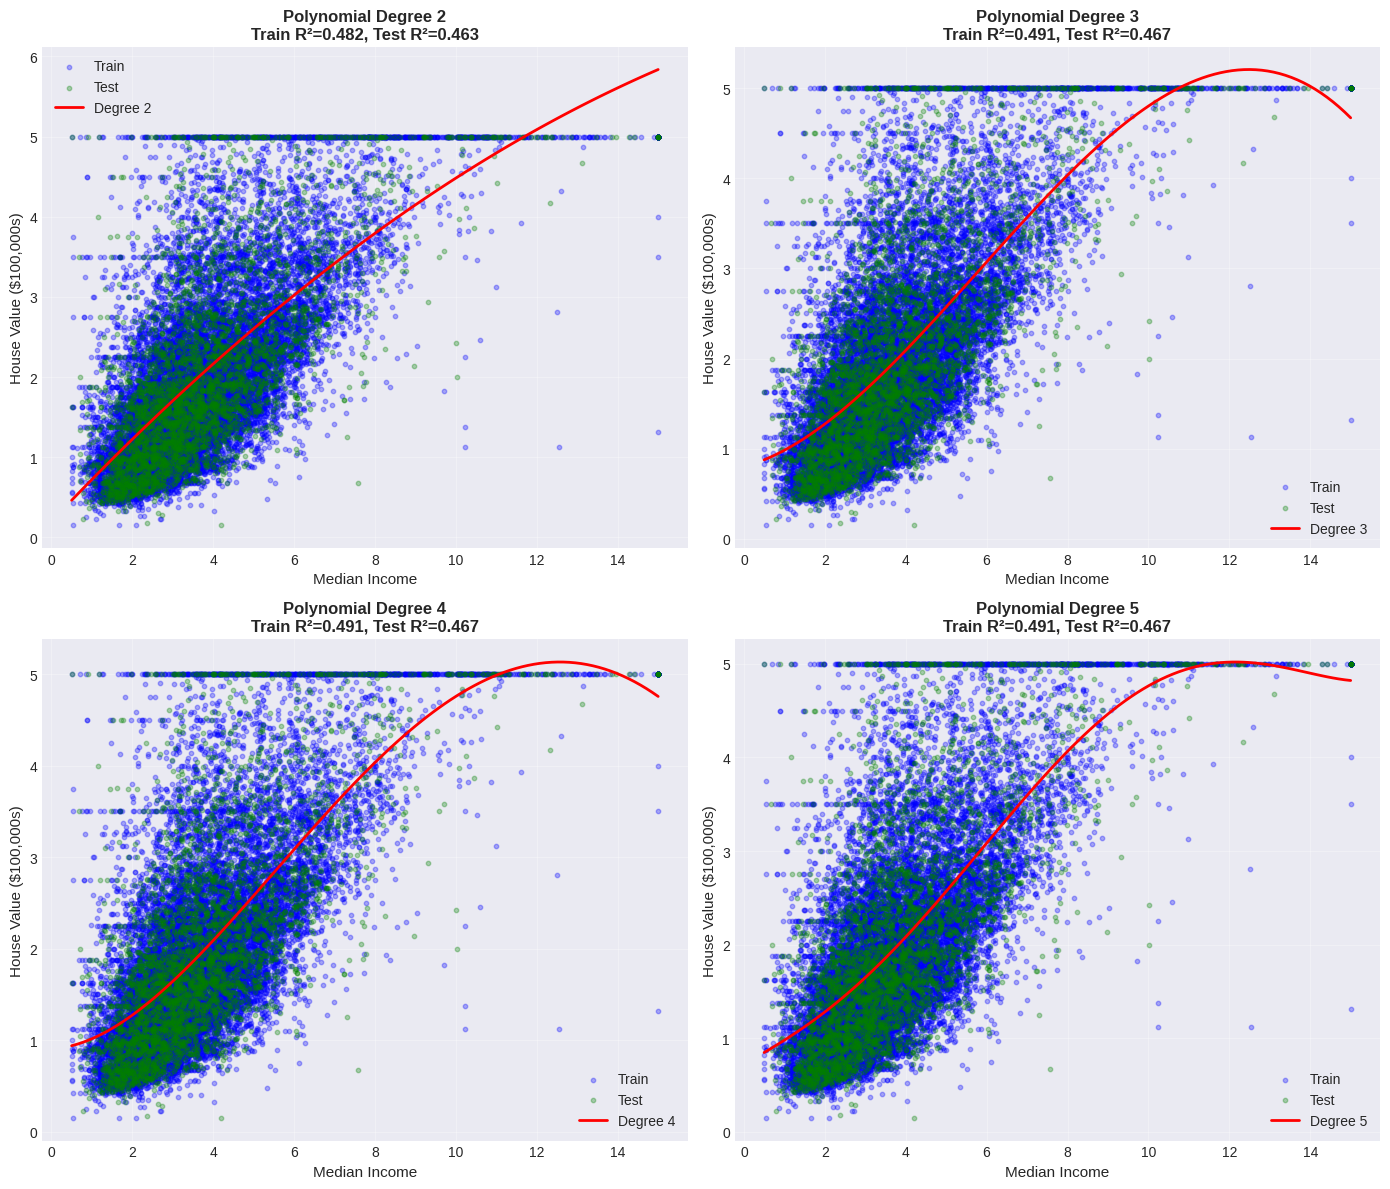

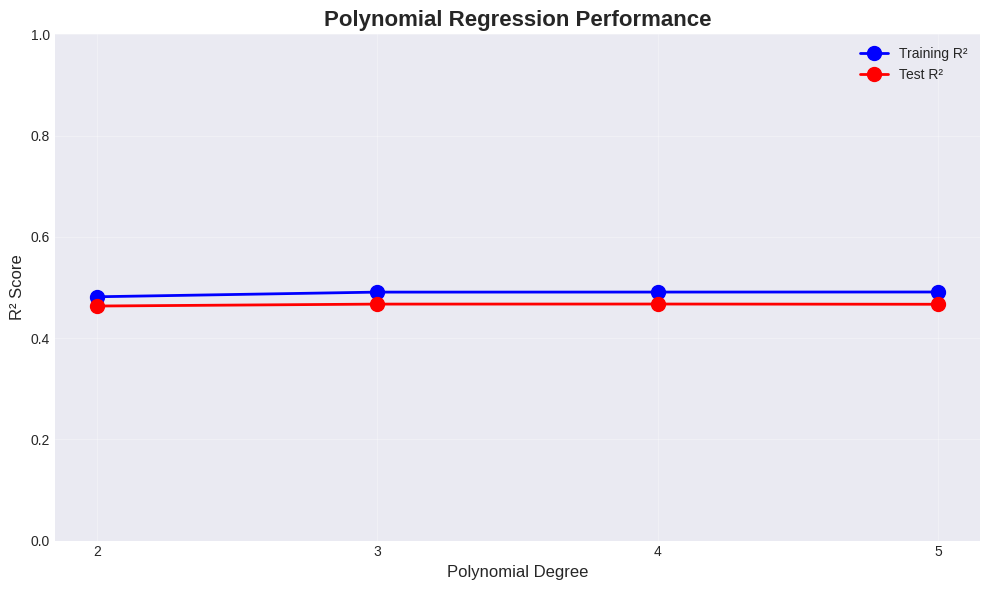

In [ ]:

print("\n" + "="*60)
print("POLYNOMIAL REGRESSION")
print("="*60)

# Test different polynomial degrees
degrees = [2, 3, 4, 5]
train_scores = []
test_scores = []
models = []

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, degree in enumerate(degrees):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train[['MedInc']])
    X_test_poly = poly.transform(X_test[['MedInc']])

    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    models.append(model)

    # Predictions
    y_pred_train = model.predict(X_train_poly)
    y_pred_test = model.predict(X_test_poly)

    # Scores
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_scores.append(train_r2)
    test_scores.append(test_r2)

    # Plot
    axes[idx].scatter(X_train['MedInc'], y_train, alpha=0.3, label='Train', color='blue', s=10)
    axes[idx].scatter(X_test['MedInc'], y_test, alpha=0.3, label='Test', color='green', s=10)

    # Plot polynomial curve
    x_sorted = np.linspace(X['MedInc'].min(), X['MedInc'].max(), 100).reshape(-1, 1)
    x_poly_sorted = poly.transform(x_sorted)
    y_poly_sorted = model.predict(x_poly_sorted)

    axes[idx].plot(x_sorted, y_poly_sorted, 'red', linewidth=2, label=f'Degree {degree}')
    axes[idx].set_xlabel('Median Income', fontsize=11)
    axes[idx].set_ylabel('House Value ($100,000s)', fontsize=11)
    axes[idx].set_title(f'Polynomial Degree {degree}\nTrain R²={train_r2:.3f}, Test R²={test_r2:.3f}',
                        fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# R² comparison
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_scores, 'bo-', linewidth=2, markersize=10, label='Training R²')
plt.plot(degrees, test_scores, 'ro-', linewidth=2, markersize=10, label='Test R²')
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Polynomial Regression Performance', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(degrees)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


MODEL COMPARISON
             Model     RMSE ($)       R²      MAE ($)
     Simple Linear 84209.012414 0.458859 62990.865301
   Multiple Linear 74558.138301 0.575788 53320.013050
Polynomial (deg 2) 83861.389691 0.463318 62829.155887
Polynomial (deg 3) 83564.135519 0.467116 62189.632170


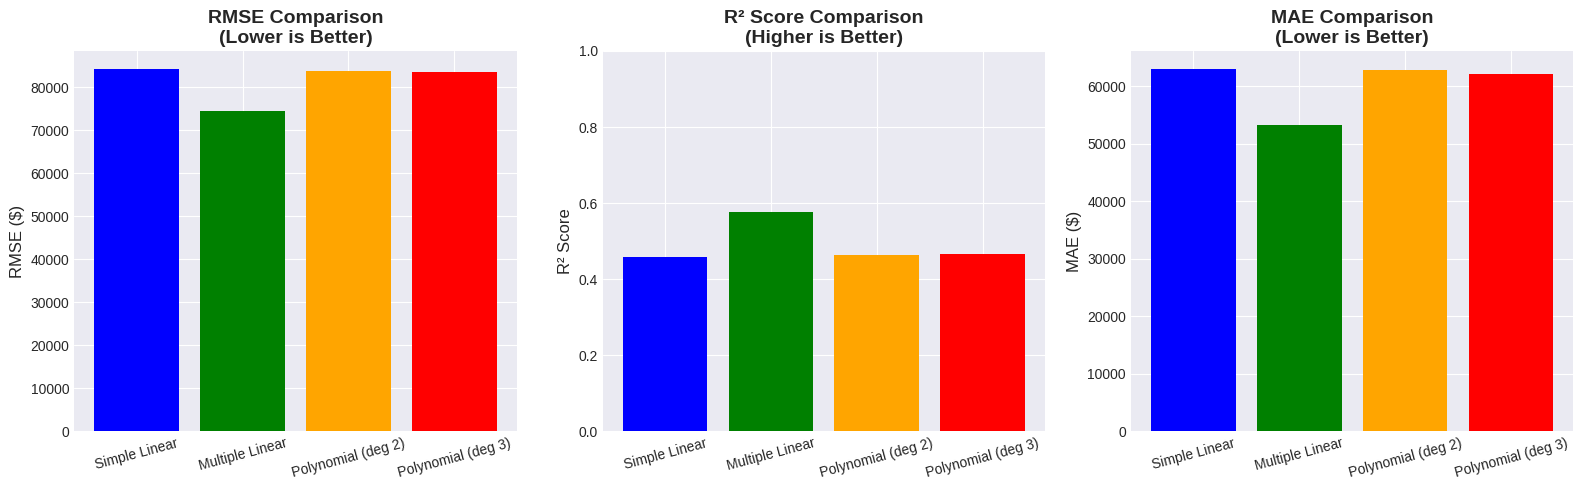


 Best Model: Multiple Linear with R² = 0.5758


In [ ]:

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Create and fit PolynomialFeatures for degree 2 and 3
poly_2 = PolynomialFeatures(degree=2, include_bias=False)
poly_3 = PolynomialFeatures(degree=3, include_bias=False)

# Fit on the training data (MedInc only, as this was the feature used for poly regression)
poly_2.fit(X_train[['MedInc']])
poly_3.fit(X_train[['MedInc']])

# Transform the test data using the fitted PolynomialFeatures
X_test_poly2 = poly_2.transform(X_test[['MedInc']])
X_test_poly3 = poly_3.transform(X_test[['MedInc']])

# Compare all models
models_comparison = pd.DataFrame({
    'Model': ['Simple Linear', 'Multiple Linear', 'Polynomial (deg 2)', 'Polynomial (deg 3)'],
    'RMSE': [
        simple_rmse,
        multi_rmse,
        np.sqrt(mean_squared_error(y_test, models[0].predict(X_test_poly2))),
        np.sqrt(mean_squared_error(y_test, models[1].predict(X_test_poly3)))
    ],
    'R²': [
        simple_r2,
        multi_r2,
        r2_score(y_test, models[0].predict(X_test_poly2)),
        r2_score(y_test, models[1].predict(X_test_poly3))
    ],
    'MAE': [
        simple_mae,
        multi_mae,
        mean_absolute_error(y_test, models[0].predict(X_test_poly2)),
        mean_absolute_error(y_test, models[1].predict(X_test_poly3))
    ]
})

# Convert to dollars
models_comparison['RMSE ($)'] = models_comparison['RMSE'] * 100000
models_comparison['MAE ($)'] = models_comparison['MAE'] * 100000

print(models_comparison[['Model', 'RMSE ($)', 'R²', 'MAE ($)']].to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE
axes[0].bar(models_comparison['Model'], models_comparison['RMSE ($)'],
            color=['blue', 'green', 'orange', 'red'])
axes[0].set_title('RMSE Comparison\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)

# R²
axes[1].bar(models_comparison['Model'], models_comparison['R²'],
            color=['blue', 'green', 'orange', 'red'])
axes[1].set_title('R² Score Comparison\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)

# MAE
axes[2].bar(models_comparison['Model'], models_comparison['MAE ($)'],
            color=['blue', 'green', 'orange', 'red'])
axes[2].set_title('MAE Comparison\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('MAE ($)', fontsize=12)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Best model
best_model_idx = models_comparison['R²'].idxmax()
best_model_name = models_comparison.loc[best_model_idx, 'Model']
best_r2 = models_comparison.loc[best_model_idx, 'R²']

print(f"\n Best Model: {best_model_name} with R² = {best_r2:.4f}")


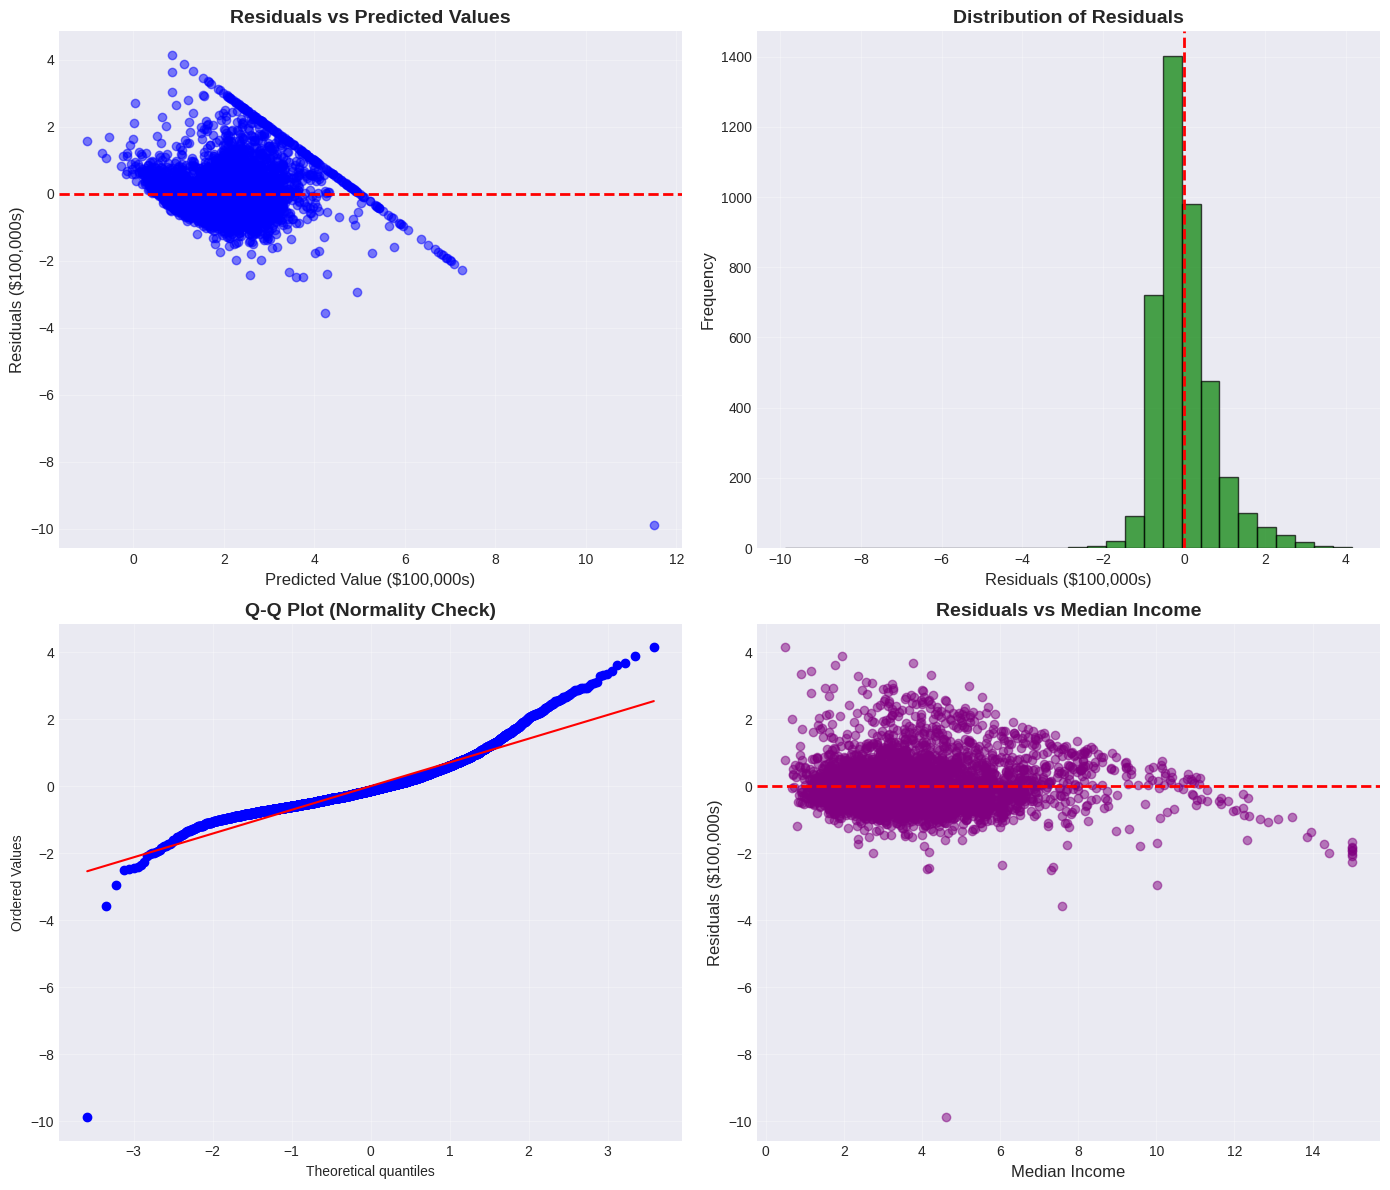


RESIDUAL ANALYSIS
Mean of residuals: 0.003479
Standard deviation: 0.745573
Min residual: -9.875331
Max residual: 4.148388
Skewness: 0.5457
Kurtosis: 10.0701


In [ ]:

# Using Multiple Linear Regression as best model
residuals = y_test - y_pred_multi_test

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Residuals vs Predicted
axes[0, 0].scatter(y_pred_multi_test, residuals, alpha=0.5, color='blue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Value ($100,000s)', fontsize=12)
axes[0, 0].set_ylabel('Residuals ($100,000s)', fontsize=12)
axes[0, 0].set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Histogram of residuals
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuals ($100,000s)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Residuals vs MedInc
axes[1, 1].scatter(X_test['MedInc'], residuals, alpha=0.5, color='purple')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Median Income', fontsize=12)
axes[1, 1].set_ylabel('Residuals ($100,000s)', fontsize=12)
axes[1, 1].set_title('Residuals vs Median Income', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual statistics
print("\n" + "="*60)
print("RESIDUAL ANALYSIS")
print("="*60)
print(f"Mean of residuals: {np.mean(residuals):.6f}")
print(f"Standard deviation: {np.std(residuals):.6f}")
print(f"Min residual: {np.min(residuals):.6f}")
print(f"Max residual: {np.max(residuals):.6f}")
print(f"Skewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")


FEATURE IMPORTANCE ANALYSIS
   Feature  Coefficient  Coefficient ($)  Absolute Importance  Importance (%)
  Latitude    -0.896929    -89692.887664             0.896929       26.222108
 Longitude    -0.869842    -86984.177524             0.869842       25.430205
    MedInc     0.854383     85438.303093             0.854383       24.978262
 AveBedrms     0.339259     33925.949059             0.339259        9.918400
  AveRooms    -0.294410    -29441.013447             0.294410        8.607209
  HouseAge     0.122546     12254.623808             0.122546        3.582693
  AveOccup    -0.040829     -4082.910309             0.040829        1.193657
Population    -0.002308      -230.772315             0.002308        0.067467


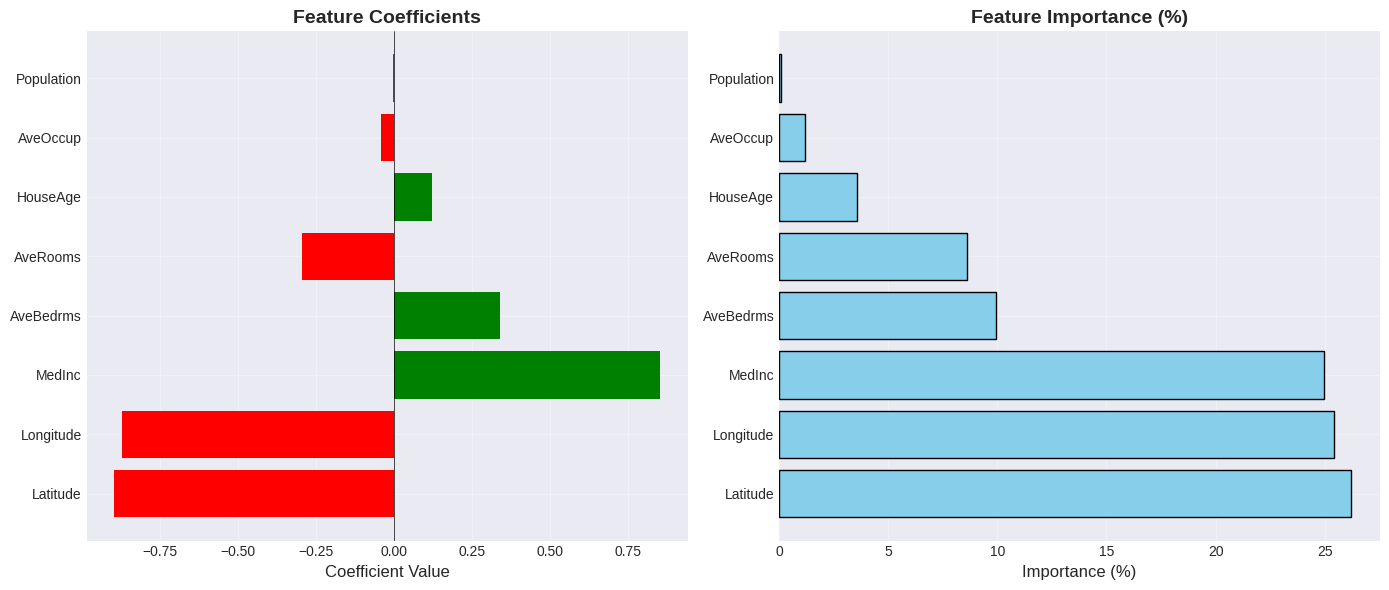


Top 3 Most Important Features:
1. Latitude: 26.2% importance
2. Longitude: 25.4% importance
3. MedInc: 25.0% importance


In [ ]:

# Using multiple linear regression coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multi_model.coef_,
    'Coefficient ($)': multi_model.coef_ * 100000,
    'Absolute Importance': np.abs(multi_model.coef_)
}).sort_values('Absolute Importance', ascending=False)

# Normalize importance
feature_importance['Importance (%)'] = (feature_importance['Absolute Importance'] /
                                        feature_importance['Absolute Importance'].sum() * 100)

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)
print(feature_importance.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Coefficients
colors = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient']]
axes[0].barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Feature Coefficients', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Importance percentage
axes[1].barh(feature_importance['Feature'], feature_importance['Importance (%)'],
             color='skyblue', edgecolor='black')
axes[1].set_xlabel('Importance (%)', fontsize=12)
axes[1].set_title('Feature Importance (%)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Top 3 important features
top_features = feature_importance.head(3)['Feature'].tolist()
print(f"\nTop 3 Most Important Features:")
for i, feature in enumerate(top_features, 1):
    importance = feature_importance[feature_importance['Feature'] == feature]['Importance (%)'].values[0]
    print(f"{i}. {feature}: {importance:.1f}% importance")

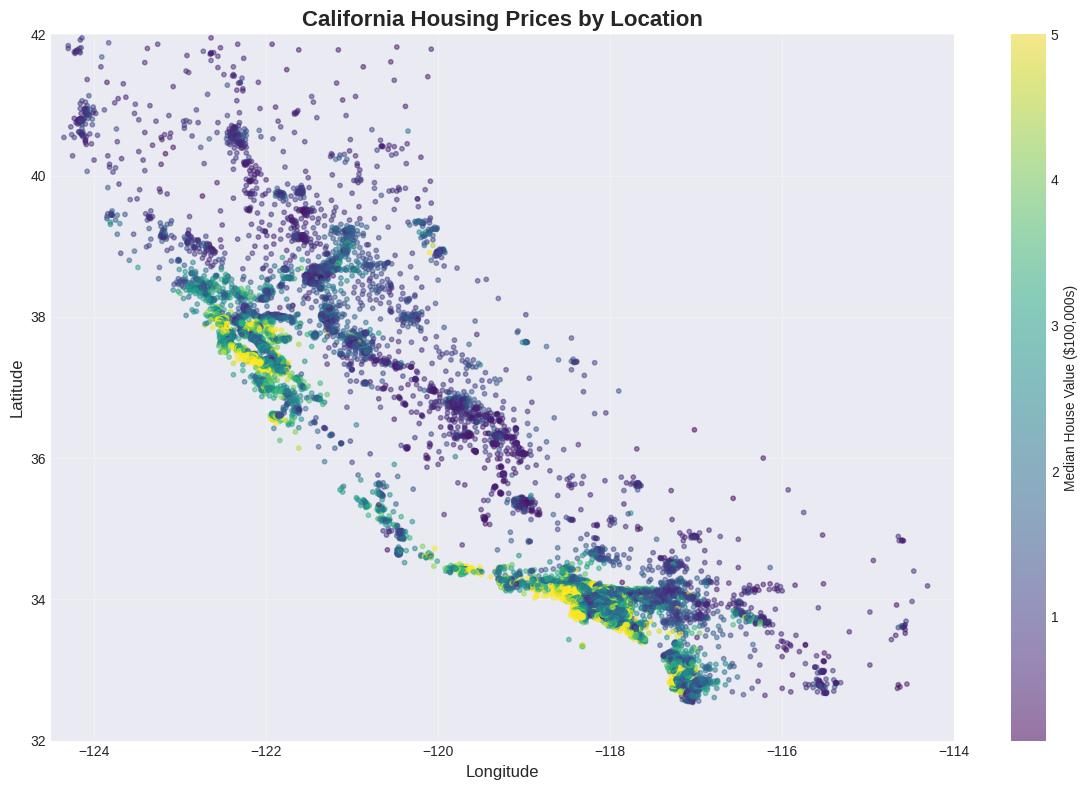


PRICES BY REGION
           mean    std  count  Mean ($)   Std ($)
Region                                           
Far West  2.458  1.321   1743  245800.0  132100.0
West      1.970  1.099   6237  197000.0  109900.0
Central   2.265  1.417   3985  226500.0  141700.0
East      2.000  0.973   8460  200000.0   97300.0
Far East  0.800  0.422    215   80000.0   42200.0


In [ ]:

# Create a simple geographic visualization
plt.figure(figsize=(12, 8))

# Scatter plot of houses by location, colored by value
scatter = plt.scatter(df['Longitude'], df['Latitude'],
                     c=df['MedHouseVal'], cmap='viridis',
                     alpha=0.5, s=10)

plt.colorbar(scatter, label='Median House Value ($100,000s)')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('California Housing Prices by Location', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add state outline approximation
plt.xlim(-124.5, -114)
plt.ylim(32, 42)

plt.tight_layout()
plt.show()

# Price by region (using simple binning)
df['Region'] = pd.cut(df['Longitude'], bins=5, labels=['Far West', 'West', 'Central', 'East', 'Far East'])

region_stats = df.groupby('Region')['MedHouseVal'].agg(['mean', 'std', 'count']).round(3)
region_stats['Mean ($)'] = region_stats['mean'] * 100000
region_stats['Std ($)'] = region_stats['std'] * 100000

print("\n" + "="*60)
print("PRICES BY REGION")
print("="*60)
print(region_stats.to_string())


FINAL SUMMARY - CALIFORNIA HOUSING
         Metric                          Value
   Dataset Size                  20640 samples
  Features Used                     9 features
Target Variable Median House Value ($100,000s)

MODEL PERFORMANCE SUMMARY
             Model     RMSE ($)       R²      MAE ($)
     Simple Linear 84209.012414 0.458859 62990.865301
   Multiple Linear 74558.138301 0.575788 53320.013050
Polynomial (deg 2) 83861.389691 0.463318 62829.155887
Polynomial (deg 3) 83564.135519 0.467116 62189.632170

KEY FINDINGS
1. Most Important Feature: Latitude
   - Importance: 26.2%
   - Impact: $-89,692.89 per unit

2. Best Performing Model: Multiple Linear
   - R² Score: 0.5758
   - RMSE: $74,558.14

3. Key Insights:
   - Median income (MedInc) has strongest positive correlation with house prices
   - House prices vary significantly by geographic location
   - Multiple features together predict better than single feature
   - Polynomial regression can capture non-linear relations

<Figure size 1200x600 with 0 Axes>

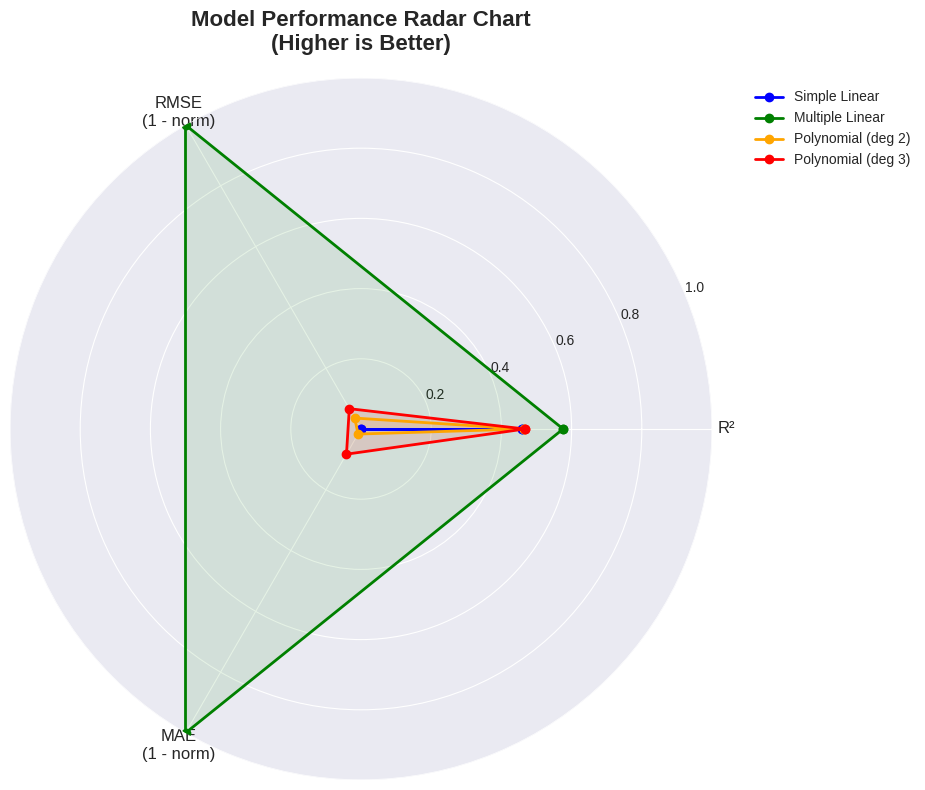


 LAB COMPLETE - CONGRATULATIONS!


In [ ]:

print("\n" + "="*60)
print("FINAL SUMMARY - CALIFORNIA HOUSING")
print("="*60)

# Create final comparison table
final_summary = pd.DataFrame({
    'Metric': ['Dataset Size', 'Features Used', 'Target Variable'],
    'Value': [
        f"{df.shape[0]} samples",
        f"{df.shape[1]-1} features",
        'Median House Value ($100,000s)'
    ]
})
print(final_summary.to_string(index=False))

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(models_comparison[['Model', 'RMSE ($)', 'R²', 'MAE ($)']].to_string(index=False))

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

# Find most important feature
most_important = feature_importance.iloc[0]
print(f"1. Most Important Feature: {most_important['Feature']}")
print(f"   - Importance: {most_important['Importance (%)']:.1f}%")
print(f"   - Impact: ${most_important['Coefficient'] * 100000:,.2f} per unit")

# Best performing model
best = models_comparison.iloc[models_comparison['R²'].idxmax()]
print(f"\n2. Best Performing Model: {best['Model']}")
print(f"   - R² Score: {best['R²']:.4f}")
print(f"   - RMSE: ${best['RMSE ($)']:,.2f}")

print("\n3. Key Insights:")
print("   - Median income (MedInc) has strongest positive correlation with house prices")
print("   - House prices vary significantly by geographic location")
print("   - Multiple features together predict better than single feature")
print("   - Polynomial regression can capture non-linear relationships")

print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)
print("✓ Use Multiple Linear Regression for interpretability")
print("✓ Consider Polynomial Regression for non-linear patterns")
print("✓ Always scale features for coefficient comparison")
print("✓ Check residuals for model assumptions")
print("✓ Location (Latitude/Longitude) is important - consider spatial models")
print("="*60)

# Final visualization - Model performance summary
plt.figure(figsize=(12, 6))

# Create radar chart for model comparison
from math import pi

# Normalize metrics for radar chart
metrics = ['R²', 'RMSE_norm', 'MAE_norm']
models_radar = models_comparison['Model'].tolist()

# Normalize (higher is better for all)
r2_norm = models_comparison['R²']
rmse_norm = 1 - (models_comparison['RMSE'] - models_comparison['RMSE'].min()) / (models_comparison['RMSE'].max() - models_comparison['RMSE'].min())
mae_norm = 1 - (models_comparison['MAE'] - models_comparison['MAE'].min()) / (models_comparison['MAE'].max() - models_comparison['MAE'].min())

# Radar chart
angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

colors = ['blue', 'green', 'orange', 'red']
for i, model in enumerate(models_radar):
    values = [r2_norm[i], rmse_norm[i], mae_norm[i]]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['R²', 'RMSE\n(1 - norm)', 'MAE\n(1 - norm)'], fontsize=12)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.set_title('Model Performance Radar Chart\n(Higher is Better)', fontsize=16, fontweight='bold', pad=20)
ax.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(" LAB COMPLETE - CONGRATULATIONS!")
print("="*60)
